In [41]:
import numpy as np
import pandas as pd

In [42]:
df = pd.read_csv(r'C:\Users\konta\Documents\DIV_Academy\Module2(From_29_nov)\data\Mall_Customers.csv')

In [43]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [44]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [81]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
cat_cols = ['Gender']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols)  
])

df_dropped = df.drop('CustomerID', axis=1)

In [82]:
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

pipeline = Pipeline([
    ('prep', preprocessor),
    ('kmeans', KMeans(n_clusters=5, random_state=42))
])

pipeline.fit(df.drop('CustomerID', axis=1))

X_scaled = pipeline['prep'].transform(df_dropped)

centers = pipeline['kmeans'].cluster_centers_

df['Cluster'] = pipeline.predict(df_dropped)

c:\Users\konta\anaconda3\envs\ds\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


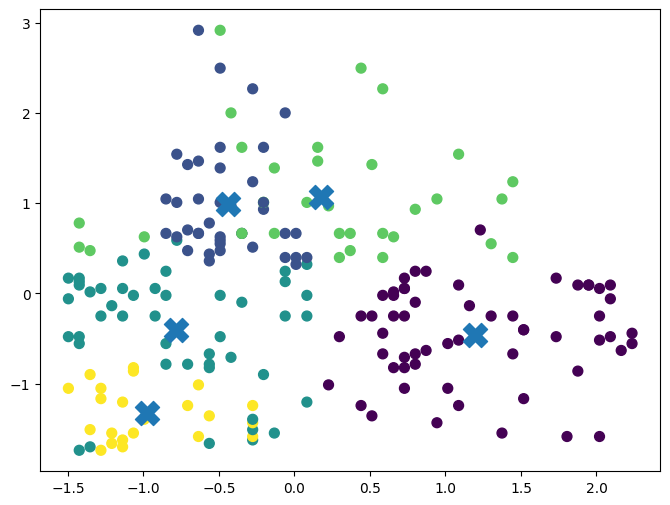

In [83]:
import matplotlib.pyplot as plt

centers = pipeline['kmeans'].cluster_centers_

plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=df['Cluster'], s=50)

plt.scatter(centers[:,0], centers[:,1], s=300, marker='X')

plt.show()

In [84]:
from sklearn.metrics import silhouette_score

# Get labels
labels = pipeline.predict(df_dropped)

# Use the scaled version (important!)
X_scaled = pipeline['prep'].transform(df_dropped)

score = silhouette_score(X_scaled, labels)

print("Silhouette Score:", score)

Silhouette Score: 0.34977050035201074


In [59]:
pd.DataFrame(X_scaled)

,0,1,2,3
0,-1.424569,-1.738999,-0.434801,1.0
1,-1.281035,-1.738999,1.195704,1.0
2,-1.352802,-1.700830,-1.715913,0.0
3,-1.137502,-1.700830,1.040418,0.0
4,-0.563369,-1.662660,-0.395980,0.0
...,...,...,...,...
195,-0.276302,2.268791,1.118061,0.0
196,0.441365,2.497807,-0.861839,0.0
197,-0.491602,2.497807,0.923953,1.0
198,-0.491602,2.917671,-1.250054,1.0
